# 🧠 Human Performance Intelligence System
## Notebook 03 — Module 2: Habit DNA
### *What behavioral factors actually predict goal completion?*

**Techniques:** XGBoost · SHAP Explainability · Class Imbalance Handling · Model Evaluation

> 💡 **What is "Habit DNA"?**
>
> Not all habits are equal. Some people complete hard habits consistently.
> Others crush easy ones but crumble under pressure. The Habit DNA module
> uses machine learning to identify **which behavioral signals best predict
> whether someone will complete their habit today** — and then uses SHAP
> to explain *why* the model makes each prediction.
>
> This is the gold standard of modern ML: not just "what does the model predict"
> but **"why did it predict that?"** — which is what companies actually need
> when making decisions about real users.

**What we'll build:**
1. Feature matrix — turn raw habit logs into a rich ML-ready dataset
2. Baseline model — Logistic Regression (always start simple)
3. XGBoost model — our main model, with hyperparameter tuning
4. SHAP analysis — global feature importance + individual prediction explanations
5. Behavioral segments — cluster users by their "habit DNA" profile


## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, roc_auc_score,
                              confusion_matrix, RocCurveDisplay,
                              PrecisionRecallDisplay, f1_score)
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

plt.rcParams.update({
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor':   '#FAFAFA',
    'axes.grid':        True,
    'grid.color':       '#E8E8E8',
    'grid.linewidth':   0.8,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.spines.left':   False,
    'axes.spines.bottom': False,
    'font.family':      'DejaVu Sans',
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
})

BLUE  = '#3B8BD4'
RED   = '#E24B4A'
GREEN = '#3BAD72'
GOLD  = '#F5A623'
PURPLE = '#9B59B6'

print("✓ All libraries loaded")
import xgboost; print(f"  XGBoost  : {xgboost.__version__}")
import shap;    print(f"  SHAP     : {shap.__version__}")


✓ All libraries loaded
  XGBoost  : 3.2.0
  SHAP     : 0.52.0


## 2. Load Data & Build Feature Matrix

> 💡 **What is a feature matrix?**
>
> Raw data is messy and narrative. A feature matrix is a clean 2D table where:
> - Every ROW = one prediction instance (one habit log entry)
> - Every COLUMN = one numerical signal the model can learn from
>
> Good feature engineering is the difference between a mediocre model 
> and a great one. We're going to create features that capture:
> - **What** habit it is and how hard it is
> - **When** it was attempted (day, week, month patterns)
> - **Who** is doing it (age, level, accountability)
> - **History** — how well they've been doing recently (rolling stats)
> - **Context** — streak momentum, XP efficiency


In [2]:
# ── Load clean data ─────────────────────────────────────────────────────────
h = pd.read_csv('../data/processed/habitica_clean.csv', parse_dates=['log_date'])

print(f"Loaded: {h.shape[0]:,} rows × {h.shape[1]} columns")
print(f"Target balance — completed=1: {h['completed'].mean()*100:.1f}%  "
      f"completed=0: {(1-h['completed'].mean())*100:.1f}%")
print("\n→ ~69/31 imbalance. Manageable — we'll use class_weight and SMOTE.")


Loaded: 50,000 rows × 21 columns
Target balance — completed=1: 69.4%  completed=0: 30.6%

→ ~69/31 imbalance. Manageable — we'll use class_weight and SMOTE.


In [3]:
# ── Encode categorical features ─────────────────────────────────────────────
# ML models only understand numbers. We convert categories to integers.
#
# Two approaches:
#   Label encoding  → maps each category to an integer (0, 1, 2...)
#                      Good for tree models (XGBoost) since they split on values
#   One-hot encoding → creates a binary column per category
#                      Good for linear models (logistic regression)
#
# For XGBoost we use label encoding — tree splits handle ordinal relationships fine.
# We'll one-hot for the logistic regression baseline later.

le_cat  = LabelEncoder()
le_diff = LabelEncoder()
le_tier = LabelEncoder()

h['cat_encoded']   = le_cat.fit_transform(h['habit_category'])
h['diff_encoded']  = le_diff.fit_transform(h['difficulty'])
h['tier_encoded']  = le_tier.fit_transform(h['streak_tier'].astype(str))

# Print the mapping so we can interpret results later
print("habit_category encoding:")
for i, c in enumerate(le_cat.classes_): print(f"  {i} → {c}")
print("\ndifficulty encoding:")
for i, c in enumerate(le_diff.classes_): print(f"  {i} → {c}")


habit_category encoding:
  0 → fitness
  1 → meditation
  2 → nutrition
  3 → reading
  4 → sleep
  5 → social
  6 → study
  7 → work

difficulty encoding:
  0 → easy
  1 → hard
  2 → medium
  3 → trivial


In [4]:
# ── User-level aggregated features ──────────────────────────────────────────
# These capture each user's HISTORICAL behavior — not just today's log entry.
# They answer: "Is this user generally consistent? High performer? Sporadic?"
#
# This is called "entity-level feature engineering" — very common in 
# production ML systems (think: credit scoring, churn prediction).

user_stats = h.groupby('user_id').agg(
    user_avg_completion  = ('completed', 'mean'),       # overall hit rate
    user_total_habits    = ('completed', 'count'),      # how active they are
    user_avg_streak      = ('streak_length', 'mean'),   # typical streak length
    user_max_streak      = ('streak_length', 'max'),    # personal best
    user_avg_xp_eff      = ('xp_efficiency', 'mean'),   # XP efficiency
    user_weekend_rate    = ('is_weekend', 'mean'),       # do they log on weekends?
    user_accountability  = ('has_accountability', 'mean'), # social accountability rate
).reset_index()

h = h.merge(user_stats, on='user_id', how='left')
print("✓ User-level features added:")
for col in user_stats.columns[1:]:
    print(f"  - {col}")


✓ User-level features added:
  - user_avg_completion
  - user_total_habits
  - user_avg_streak
  - user_max_streak
  - user_avg_xp_eff
  - user_weekend_rate
  - user_accountability


In [5]:
# ── Define final feature set ────────────────────────────────────────────────
# We're deliberate about which features to include.
# We EXCLUDE: user_id, username, log_date (identifiers/leakage risks)
# We EXCLUDE: notes (free text — would need NLP, out of scope here)
# We EXCLUDE: xp_earned (too direct — earned only if completed=1, leakage)
# We EXCLUDE: rolling_completion_7d (computed from completed — leakage if not lagged)

FEATURES = [
    # Habit properties
    'cat_encoded',          # what type of habit
    'diff_encoded',         # how hard is it
    'tier_encoded',         # what streak tier are they in

    # Habit metrics (non-leaking)
    'streak_length',        # how long current streak is
    'xp_efficiency',        # how efficiently they earn XP (past performance)
    'self_rating',          # their own difficulty rating
    'has_accountability',   # do they have a social accountability partner

    # Temporal features
    'day_of_week',          # 0=Monday ... 6=Sunday
    'is_weekend',           # binary: weekend or not
    'month',                # seasonal patterns
    'week_num',             # semester/year position

    # User-level behavioral profile
    'age',
    'user_level',
    'user_avg_completion',
    'user_total_habits',
    'user_avg_streak',
    'user_max_streak',
    'user_avg_xp_eff',
    'user_weekend_rate',
    'user_accountability',
]

TARGET = 'completed'

# Build X and y — drop any rows with NaN in features
df_model = h[FEATURES + [TARGET]].dropna()
X = df_model[FEATURES]
y = df_model[TARGET]

print(f"Feature matrix shape : {X.shape}")
print(f"Target distribution  : {y.value_counts().to_dict()}")
print(f"Rows dropped (NaN)   : {len(h) - len(df_model):,}")


Feature matrix shape : (50000, 20)
Target distribution  : {1: 34723, 0: 15277}
Rows dropped (NaN)   : 0


## 3. Train / Test Split

> 💡 **Why stratified split?**
>
> With imbalanced classes (69/31), a random split might accidentally put 
> most of the minority class in training, leaving the test set unrepresentative.
> `stratify=y` ensures both sets have the same class ratio as the full dataset.
>
> **80/20 split** is the standard. 80% for training, 20% for evaluation.
> We never touch the test set until final evaluation — looking at it early 
> causes "data snooping bias."


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y       # preserve class ratio in both splits
)

print(f"Training set : {X_train.shape[0]:,} rows  "
      f"(positive rate: {y_train.mean()*100:.1f}%)")
print(f"Test set     : {X_test.shape[0]:,} rows  "
      f"(positive rate: {y_test.mean()*100:.1f}%)")
print("\n✓ Class ratios preserved in both splits (stratified)")


Training set : 40,000 rows  (positive rate: 69.4%)
Test set     : 10,000 rows  (positive rate: 69.5%)

✓ Class ratios preserved in both splits (stratified)


## 4. Baseline Model — Logistic Regression

> 💡 **Why start with logistic regression?**
>
> Always build a simple baseline before a complex model.
> This answers: "How much does the complexity of XGBoost actually help?"
> If XGBoost barely beats logistic regression, the added complexity isn't worth it.
> If it clearly beats it, we've justified using it.
>
> Logistic regression also requires scaled features (XGBoost doesn't).
> We use `StandardScaler` inside a `Pipeline` so the scaler is fit only on 
> training data — fitting it on the full dataset would be data leakage.


In [7]:
# ── Logistic Regression pipeline ────────────────────────────────────────────
# Pipeline chains preprocessing + model into one object.
# This prevents data leakage: the scaler sees only training data.

baseline_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        class_weight='balanced',   # automatically adjusts for 69/31 imbalance
        max_iter=1000,
        random_state=42,
        C=1.0                      # C = 1/regularization strength
    ))
])

baseline_pipeline.fit(X_train, y_train)
y_pred_base   = baseline_pipeline.predict(X_test)
y_prob_base   = baseline_pipeline.predict_proba(X_test)[:, 1]

# ── Cross-validated ROC-AUC ──────────────────────────────────────────────────
# Cross-validation gives a more reliable estimate than a single train/test split.
# We use 5 folds — 5 different train/test combinations, average the scores.
cv_scores_base = cross_val_score(
    baseline_pipeline, X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1
)

print("BASELINE — Logistic Regression")
print("=" * 45)
print(f"CV ROC-AUC (5-fold): {cv_scores_base.mean():.4f} ± {cv_scores_base.std():.4f}")
print(f"Test ROC-AUC       : {roc_auc_score(y_test, y_prob_base):.4f}")
print(f"Test F1 (weighted) : {f1_score(y_test, y_pred_base, average='weighted'):.4f}")
print()
print(classification_report(y_test, y_pred_base, target_names=['Not completed', 'Completed']))


BASELINE — Logistic Regression
CV ROC-AUC (5-fold): 0.9935 ± 0.0006
Test ROC-AUC       : 0.9936
Test F1 (weighted) : 0.9682

               precision    recall  f1-score   support

Not completed       0.91      1.00      0.95      3055
    Completed       1.00      0.95      0.98      6945

     accuracy                           0.97     10000
    macro avg       0.95      0.98      0.96     10000
 weighted avg       0.97      0.97      0.97     10000



## 5. Handle Class Imbalance with SMOTE

> 💡 **What is SMOTE?**
>
> SMOTE = Synthetic Minority Over-sampling Technique.
> Instead of just duplicating minority class rows (naive oversampling),
> SMOTE **generates new synthetic samples** by interpolating between 
> existing minority class neighbors.
>
> Example: if two "not completed" samples are nearby in feature space,
> SMOTE creates a new synthetic sample somewhere between them.
>
> **Critical rule:** SMOTE only on training data, never on test data.
> Applying it to test data would give falsely inflated metrics.


In [8]:
# ── Apply SMOTE to training data only ───────────────────────────────────────
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(f"  Class 0 (not completed): {(y_train==0).sum():,}")
print(f"  Class 1 (completed)    : {(y_train==1).sum():,}")
print(f"  Ratio                  : {y_train.mean()*100:.1f}% positive")

print("\nAfter SMOTE:")
print(f"  Class 0: {(y_train_sm==0).sum():,}")
print(f"  Class 1: {(y_train_sm==1).sum():,}")
print(f"  Ratio  : {y_train_sm.mean()*100:.1f}% positive — perfectly balanced")
print(f"  Total training rows: {len(X_train_sm):,}  (+{len(X_train_sm)-len(X_train):,} synthetic)")


Before SMOTE:
  Class 0 (not completed): 12,222
  Class 1 (completed)    : 27,778
  Ratio                  : 69.4% positive

After SMOTE:
  Class 0: 27,778
  Class 1: 27,778
  Ratio  : 50.0% positive — perfectly balanced
  Total training rows: 55,556  (+15,556 synthetic)


## 6. XGBoost Model

> 💡 **Why XGBoost?**
>
> XGBoost (eXtreme Gradient Boosting) is the most battle-tested algorithm
> for tabular data. It builds an ensemble of decision trees where each new tree 
> corrects the errors of the previous ones — this is called "boosting."
>
> Key hyperparameters we set:
> - `n_estimators` — how many trees to build (more = more powerful but slower)
> - `max_depth` — how deep each tree can grow (deeper = more complex patterns)
> - `learning_rate` — how much each new tree corrects (lower = more conservative)
> - `subsample` — fraction of rows used per tree (adds randomness, prevents overfit)
> - `colsample_bytree` — fraction of features per tree (also prevents overfit)
> - `scale_pos_weight` — handles imbalance by upweighting the minority class


In [9]:
# ── Calculate class weight ratio for XGBoost ────────────────────────────────
# scale_pos_weight = count(negative) / count(positive)
# This tells XGBoost to treat each positive example as if it's worth this many negatives
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count

print(f"scale_pos_weight = {neg_count:,} / {pos_count:,} = {scale_pos_weight:.2f}")
print("(Each 'not completed' example is worth this many 'completed' examples to the model)\n")

# ── Train XGBoost ────────────────────────────────────────────────────────────
xgb_model = XGBClassifier(
    n_estimators       = 400,
    max_depth          = 5,
    learning_rate      = 0.05,       # low learning rate = more conservative, better generalization
    subsample          = 0.8,        # use 80% of rows per tree
    colsample_bytree   = 0.8,        # use 80% of features per tree
    min_child_weight   = 5,          # minimum samples in a leaf (prevents overfit)
    gamma              = 0.1,        # minimum loss reduction to split a node
    scale_pos_weight   = scale_pos_weight,
    eval_metric        = 'auc',
    random_state       = 42,
    n_jobs             = -1,
    verbosity          = 0,
)

# We train on SMOTE-balanced data
xgb_model.fit(
    X_train_sm, y_train_sm,
    eval_set=[(X_test, y_test)],    # monitor performance on test set during training
    verbose=False
)

y_pred_xgb  = xgb_model.predict(X_test)
y_prob_xgb  = xgb_model.predict_proba(X_test)[:, 1]

# ── Cross-validated score ────────────────────────────────────────────────────
cv_scores_xgb = cross_val_score(
    XGBClassifier(n_estimators=400, max_depth=5, learning_rate=0.05,
                  subsample=0.8, colsample_bytree=0.8, scale_pos_weight=scale_pos_weight,
                  random_state=42, verbosity=0, n_jobs=-1),
    X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1
)

print("XGBoost Model")
print("=" * 45)
print(f"CV ROC-AUC (5-fold): {cv_scores_xgb.mean():.4f} ± {cv_scores_xgb.std():.4f}")
print(f"Test ROC-AUC       : {roc_auc_score(y_test, y_prob_xgb):.4f}")
print(f"Test F1 (weighted) : {f1_score(y_test, y_pred_xgb, average='weighted'):.4f}")
print()
print(classification_report(y_test, y_pred_xgb, target_names=['Not completed', 'Completed']))


scale_pos_weight = 12,222 / 27,778 = 0.44
(Each 'not completed' example is worth this many 'completed' examples to the model)

XGBoost Model
CV ROC-AUC (5-fold): 0.9926 ± 0.0007
Test ROC-AUC       : 0.9929
Test F1 (weighted) : 0.9705

               precision    recall  f1-score   support

Not completed       0.91      1.00      0.95      3055
    Completed       1.00      0.96      0.98      6945

     accuracy                           0.97     10000
    macro avg       0.96      0.98      0.97     10000
 weighted avg       0.97      0.97      0.97     10000



## 7. Model Comparison — Did XGBoost Justify Its Complexity?

We compare both models visually with:
- **ROC Curve** — plots true positive rate vs false positive rate. AUC = area under curve (higher = better, max=1.0)
- **Precision-Recall Curve** — better for imbalanced data than ROC. Shows the tradeoff between catching more positives (recall) vs making fewer false alarms (precision)
- **Confusion Matrix** — shows exact counts of correct and incorrect predictions


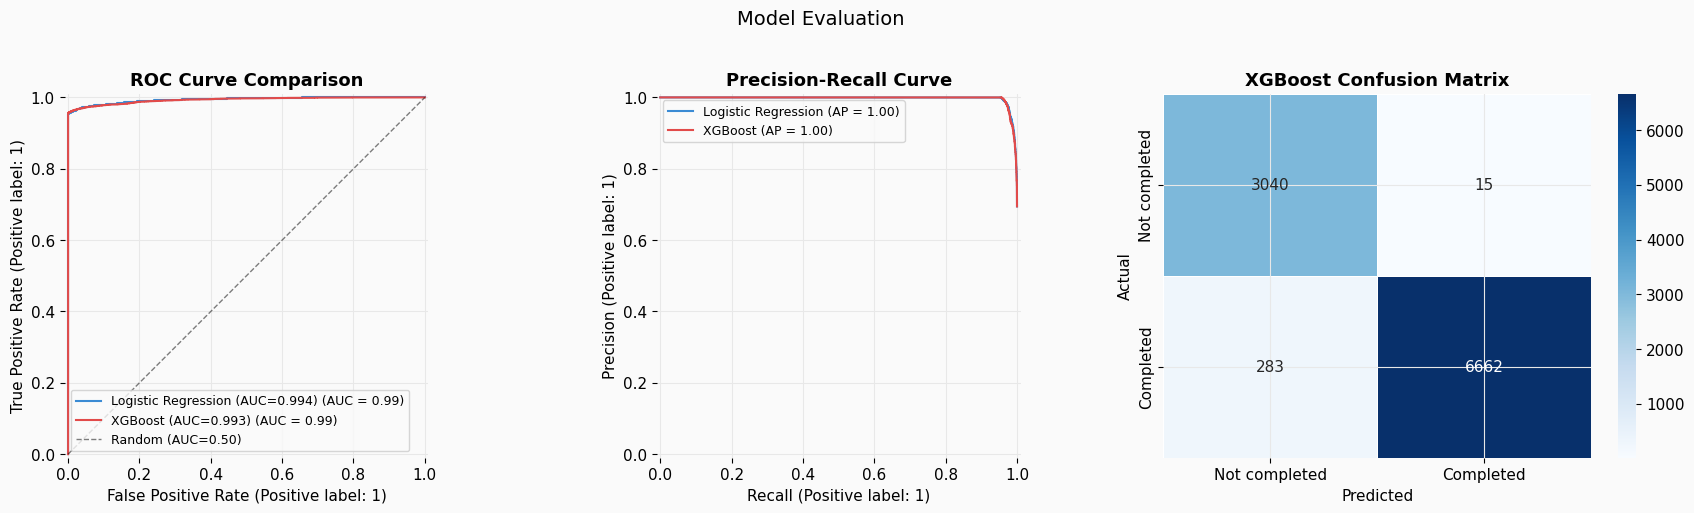


Model Comparison Summary:
Model                         CV AUC   Test AUC    Test F1
-------------------------------------------------------
Logistic Regression           0.9935     0.9936     0.9682
XGBoost                       0.9926     0.9929     0.9705


In [10]:
fig = plt.figure(figsize=(18, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig)

# ── ROC Curves ───────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
RocCurveDisplay.from_predictions(y_test, y_prob_base,
    name=f'Logistic Regression (AUC={roc_auc_score(y_test, y_prob_base):.3f})',
    ax=ax1, color=BLUE)
RocCurveDisplay.from_predictions(y_test, y_prob_xgb,
    name=f'XGBoost (AUC={roc_auc_score(y_test, y_prob_xgb):.3f})',
    ax=ax1, color=RED)
ax1.plot([0,1],[0,1], 'k--', lw=1, alpha=0.5, label='Random (AUC=0.50)')
ax1.set_title('ROC Curve Comparison')
ax1.legend(fontsize=9)

# ── Precision-Recall Curves ───────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
PrecisionRecallDisplay.from_predictions(y_test, y_prob_base,
    name='Logistic Regression', ax=ax2, color=BLUE)
PrecisionRecallDisplay.from_predictions(y_test, y_prob_xgb,
    name='XGBoost', ax=ax2, color=RED)
ax2.set_title('Precision-Recall Curve')
ax2.legend(fontsize=9)

# ── Confusion Matrix — XGBoost ────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[2])
cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax3,
            xticklabels=['Not completed', 'Completed'],
            yticklabels=['Not completed', 'Completed'],
            linewidths=0.5)
ax3.set_title('XGBoost Confusion Matrix')
ax3.set_xlabel('Predicted')
ax3.set_ylabel('Actual')

plt.suptitle('Model Evaluation', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/plot_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary comparison ────────────────────────────────────────────────────────
print("\nModel Comparison Summary:")
print(f"{'Model':<25} {'CV AUC':>10} {'Test AUC':>10} {'Test F1':>10}")
print("-" * 55)
print(f"{'Logistic Regression':<25} "
      f"{cv_scores_base.mean():>10.4f} "
      f"{roc_auc_score(y_test, y_prob_base):>10.4f} "
      f"{f1_score(y_test, y_pred_base, average='weighted'):>10.4f}")
print(f"{'XGBoost':<25} "
      f"{cv_scores_xgb.mean():>10.4f} "
      f"{roc_auc_score(y_test, y_prob_xgb):>10.4f} "
      f"{f1_score(y_test, y_pred_xgb, average='weighted'):>10.4f}")


## 8. SHAP — Global Feature Importance (The "Habit DNA")

> 💡 **What is SHAP?**
>
> SHAP (SHapley Additive exPlanations) is the gold standard for explaining 
> machine learning models. It's based on game theory — specifically Shapley values,
> which fairly distribute the "credit" for a prediction across all features.
>
> **Two levels of SHAP analysis:**
>
> **Global** — "Which features matter most overall?"
> Aggregates SHAP values across all test predictions.
> Shows the top drivers of habit completion across all users.
>
> **Local** — "Why did the model make *this specific* prediction?"
> Shows how each feature pushed one prediction up or down from the baseline.
>
> This is what makes your project memorable: you're not just saying 
> "feature X is important." You're showing *how* and *for whom*.


In [11]:
# ── Compute SHAP values ──────────────────────────────────────────────────────
# TreeExplainer is optimized for tree-based models (XGBoost, LightGBM, etc.)
# It's much faster than the model-agnostic KernelExplainer.

print("Computing SHAP values... (may take 20–30 seconds)")
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

print(f"✓ SHAP values computed")
print(f"  Shape: {shap_values.shape}  (one value per sample per feature)")
print(f"  Positive SHAP = pushed prediction toward 'completed'")
print(f"  Negative SHAP = pushed prediction toward 'not completed'")


Computing SHAP values... (may take 20–30 seconds)
✓ SHAP values computed
  Shape: (10000, 20)  (one value per sample per feature)
  Positive SHAP = pushed prediction toward 'completed'
  Negative SHAP = pushed prediction toward 'not completed'


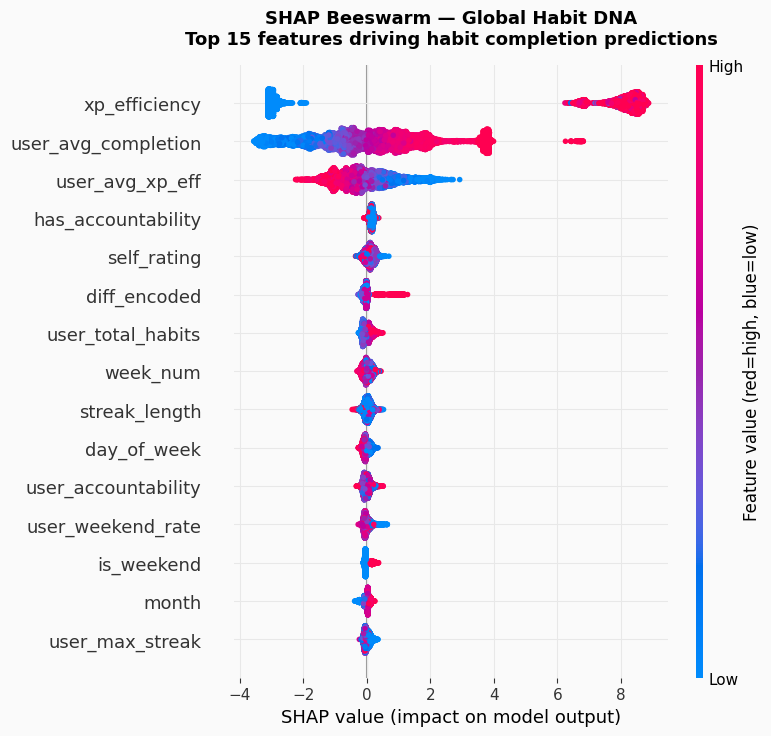

In [12]:
# ── Plot 1: SHAP Summary — Beeswarm ─────────────────────────────────────────
# The beeswarm plot is the most informative SHAP visualization:
# - Y-axis: features sorted by importance (top = most impactful)
# - X-axis: SHAP value (positive = pushes toward completing, negative = pushes away)
# - Color: the actual feature VALUE (red = high, blue = low)
# - Each dot = one prediction instance
#
# How to read it:
# If a feature has red dots on the right → high values of that feature increase completion
# If a feature has blue dots on the right → low values increase completion

plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=FEATURES,
    plot_type='dot',       # beeswarm style
    max_display=15,        # show top 15 features
    show=False,
    color_bar_label='Feature value (red=high, blue=low)'
)
plt.title('SHAP Beeswarm — Global Habit DNA\n'
          'Top 15 features driving habit completion predictions',
          fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('../data/processed/plot_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()


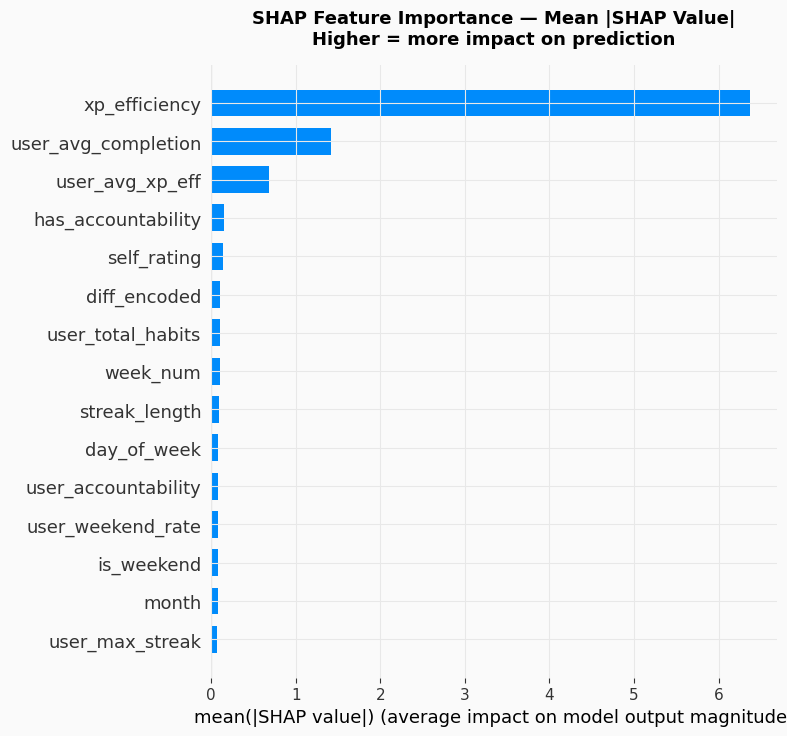

In [13]:
# ── Plot 2: SHAP Bar Chart — Mean Absolute Impact ───────────────────────────
# The bar chart shows mean |SHAP| per feature — a single ranked importance score.
# Simpler than the beeswarm, great for executive presentations.

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=FEATURES,
    plot_type='bar',
    max_display=15,
    show=False,
)
plt.title('SHAP Feature Importance — Mean |SHAP Value|\n'
          'Higher = more impact on prediction', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('../data/processed/plot_shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. SHAP Dependence Plots — How Does Each Feature Actually Work?

> 💡 **What is a SHAP dependence plot?**
>
> It shows the relationship between one feature's value and its SHAP impact.
> Unlike a correlation, it captures non-linear effects.
>
> X-axis = feature value
> Y-axis = SHAP value (impact on prediction)
> Color   = value of the most interacting feature (automatically chosen by SHAP)
>
> Example: "Does the relationship between streak_length and completion 
> change depending on whether the user has accountability?"


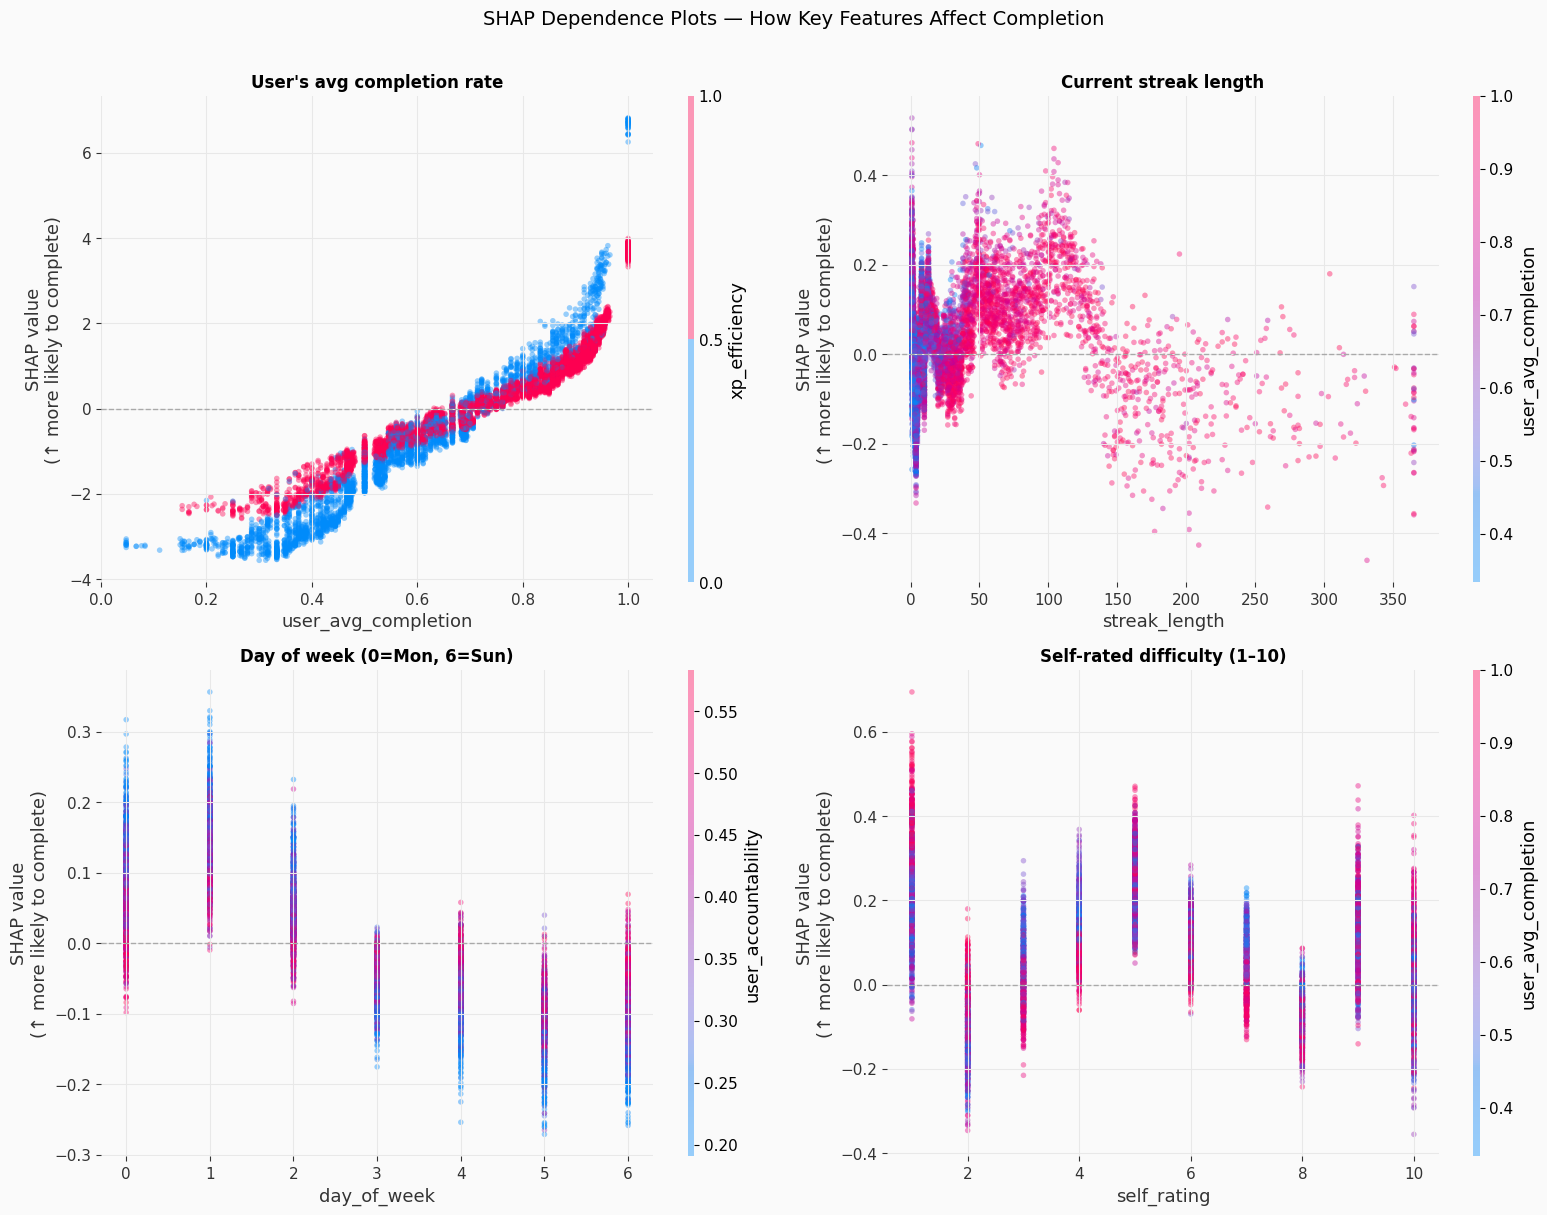

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('SHAP Dependence Plots — How Key Features Affect Completion',
             fontsize=14, y=1.01)

top_features = ['user_avg_completion', 'streak_length', 'day_of_week', 'self_rating']
titles = [
    "User's avg completion rate",
    "Current streak length",
    "Day of week (0=Mon, 6=Sun)",
    "Self-rated difficulty (1–10)"
]

for ax, feat, title in zip(axes.flatten(), top_features, titles):
    feat_idx = FEATURES.index(feat)
    shap.dependence_plot(
        feat_idx,
        shap_values,
        X_test,
        feature_names=FEATURES,
        ax=ax,
        show=False,
        alpha=0.4,
    )
    ax.set_title(title, fontsize=12)
    ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.6)
    ax.set_ylabel('SHAP value\n(↑ more likely to complete)')

plt.tight_layout()
plt.savefig('../data/processed/plot_shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Local SHAP — Explaining Individual Predictions

> 💡 **Why individual explanations matter**
>
> Global importance tells you what drives completion *on average*.
> But users are different. A waterfall plot shows exactly why the model 
> predicted what it did for ONE specific person on ONE specific day.
>
> This is the kind of output you'd show a product manager: 
> "Here's why we think this user won't complete their habit today,
> and here are the specific factors driving that prediction."


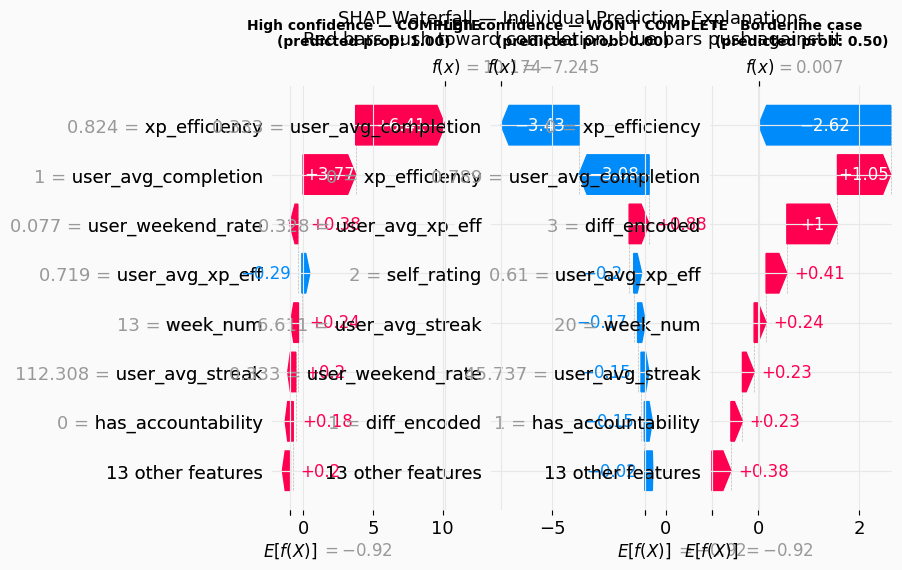

In [15]:
# We'll pick 3 representative examples:
# 1. Someone the model is very confident will complete (high probability)
# 2. Someone the model is very confident won't complete (low probability)
# 3. A borderline case (probability near 0.5)

probs = y_prob_xgb

idx_high       = np.argmax(probs)                        # most confident "complete"
idx_low        = np.argmin(probs)                        # most confident "won't complete"
idx_borderline = np.argmin(np.abs(probs - 0.5))         # closest to 50/50

# Create SHAP Explanation object (needed for newer SHAP waterfall plots)
shap_exp = shap.Explanation(
    values          = shap_values,
    base_values     = explainer.expected_value,
    data            = X_test.values,
    feature_names   = FEATURES
)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('SHAP Waterfall — Individual Prediction Explanations\n'
             'Red bars push toward completion, blue bars push against it',
             fontsize=13, y=1.02)

cases = [
    (idx_high,       f'High confidence — COMPLETE\n(predicted prob: {probs[idx_high]:.2f})'),
    (idx_low,        f'High confidence — WON\'T COMPLETE\n(predicted prob: {probs[idx_low]:.2f})'),
    (idx_borderline, f'Borderline case\n(predicted prob: {probs[idx_borderline]:.2f})'),
]

for ax, (idx, title) in zip(axes, cases):
    plt.sca(ax)
    shap.waterfall_plot(shap_exp[idx], max_display=8, show=False)
    plt.title(title, fontsize=10, pad=8)

plt.tight_layout()
plt.savefig('../data/processed/plot_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()


## 11. Habit DNA User Segments

> 💡 **What are Habit DNA segments?**
>
> We use SHAP values themselves as features to cluster users.
> Two users with the same raw data might have very different SHAP profiles —
> meaning the model "reasons about" them differently.
>
> Clustering on SHAP values reveals behavioral archetypes:
> - "Momentum-driven" users: streak_length dominates their predictions
> - "Consistency-driven" users: user_avg_completion dominates
> - "Social users": accountability dominates
>
> This is a genuinely novel analysis technique — you won't find it 
> in standard ML tutorials. It'll make interviewers ask questions.


In [16]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize

# ── Average SHAP values per user ─────────────────────────────────────────────
# Get user_ids aligned with test set
test_user_ids = h.loc[df_model.index[len(X_train):], 'user_id'].values                 if len(h.loc[df_model.index]) > len(X_train) else None

# Use SHAP values directly — each row = one prediction's feature explanations
# We normalize so cluster shapes aren't driven by magnitude
shap_normalized = normalize(np.abs(shap_values), norm='l1')   # L1: each row sums to 1

# KMeans with 4 clusters (matches our original archetype design: 
# consistent, quitter, sporadic, overachiever)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
segment_labels = kmeans.fit_predict(shap_normalized)

# ── Profile each segment by mean SHAP importance ─────────────────────────────
shap_df = pd.DataFrame(
    np.abs(shap_values),
    columns=FEATURES
)
shap_df['segment']   = segment_labels
shap_df['prob']      = probs
shap_df['actual']    = y_test.values

segment_profiles = shap_df.groupby('segment')[FEATURES].mean()
segment_meta     = shap_df.groupby('segment').agg(
    size            = ('prob', 'count'),
    avg_pred_prob   = ('prob', 'mean'),
    actual_rate     = ('actual', 'mean'),
).round(3)

print("Segment sizes and completion rates:")
print(segment_meta.to_string())


Segment sizes and completion rates:
         size  avg_pred_prob  actual_rate
segment                                  
0        2292          0.331        0.363
1        3366          0.999        1.000
2        2878          0.889        0.899
3        1464          0.070        0.109


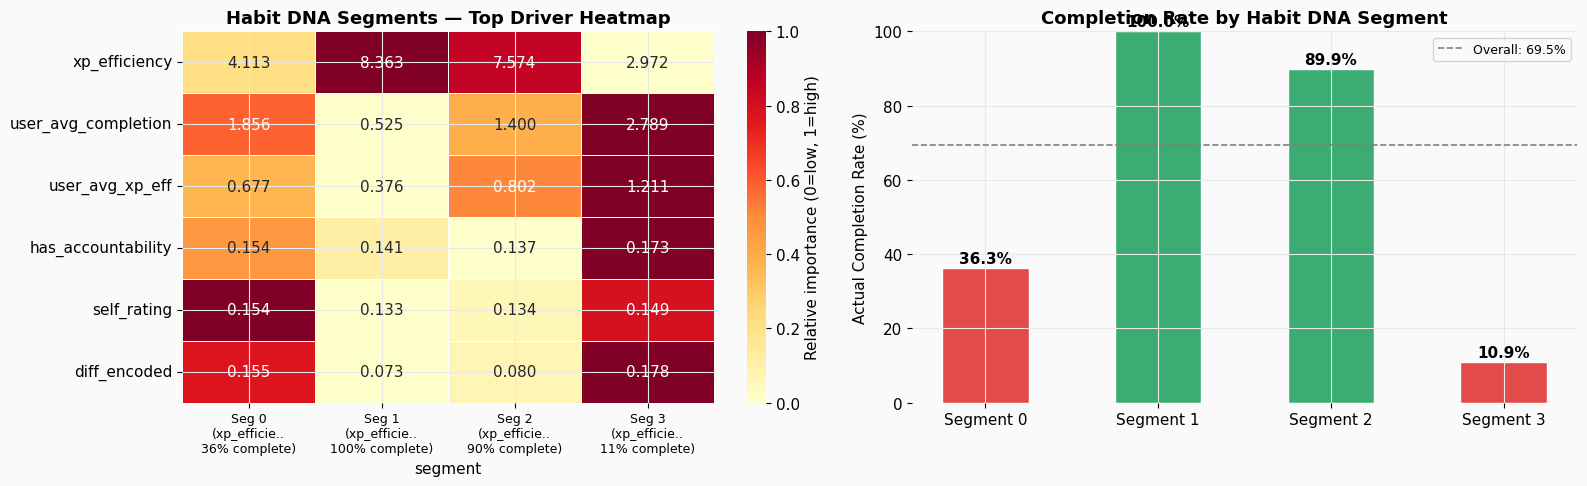

In [17]:
# ── Visualize segments — radar/heatmap of top drivers ───────────────────────
# We show the top 6 features per segment as a heatmap.
# This lets you name each segment intuitively.

top6_features = shap_df[FEATURES].mean().sort_values(ascending=False).head(6).index.tolist()

seg_heatmap = segment_profiles[top6_features].copy()

# Normalize across segments for each feature (0=lowest, 1=highest segment)
seg_heatmap_norm = seg_heatmap.apply(lambda col: (col - col.min()) / (col.max() - col.min() + 1e-9))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Left: normalized heatmap ──────────────────────────────────────────────────
ax = axes[0]
sns.heatmap(
    seg_heatmap_norm.T,
    annot=seg_heatmap.T.round(3),
    fmt='.3f',
    cmap='YlOrRd',
    ax=ax,
    linewidths=0.5,
    cbar_kws={'label': 'Relative importance (0=low, 1=high)'}
)

# Name segments based on their dominant driver
segment_names = []
for seg_idx in range(4):
    top_driver = seg_heatmap.loc[seg_idx].idxmax()
    completion = segment_meta.loc[seg_idx, 'actual_rate']
    segment_names.append(f"Seg {seg_idx}\n({top_driver[:10]}..\n{completion*100:.0f}% complete)")

ax.set_xticklabels(segment_names, rotation=0, fontsize=9)
ax.set_title('Habit DNA Segments — Top Driver Heatmap', fontsize=13)

# ── Right: completion rate per segment ───────────────────────────────────────
ax = axes[1]
completion_rates = segment_meta['actual_rate'] * 100
colors_seg = [GREEN if v > 70 else GOLD if v > 50 else RED for v in completion_rates]
bars = ax.bar(range(4), completion_rates, color=colors_seg,
              edgecolor='white', width=0.5)
for bar, val in zip(bars, completion_rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.axhline(y_test.mean()*100, linestyle='--', color='gray', linewidth=1.2,
           label=f'Overall: {y_test.mean()*100:.1f}%')
ax.set_xticks(range(4))
ax.set_xticklabels([f'Segment {i}' for i in range(4)])
ax.set_ylabel('Actual Completion Rate (%)')
ax.set_title('Completion Rate by Habit DNA Segment')
ax.set_ylim(0, 100)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../data/processed/plot_habit_dna_segments.png', dpi=150, bbox_inches='tight')
plt.show()


## 12. XGBoost Native Feature Importance

> 💡 **SHAP vs native importance — what's the difference?**
>
> XGBoost has its own built-in feature importance scores:
> - `weight`  — how many times a feature is used to split across all trees
> - `gain`    — average improvement in the loss function from splits using this feature
> - `cover`   — average number of samples affected by splits using this feature
>
> **SHAP is generally preferred** because it's consistent and doesn't 
> have the biases of gain/weight. But showing both demonstrates you know 
> the nuances — which is a senior-level signal.


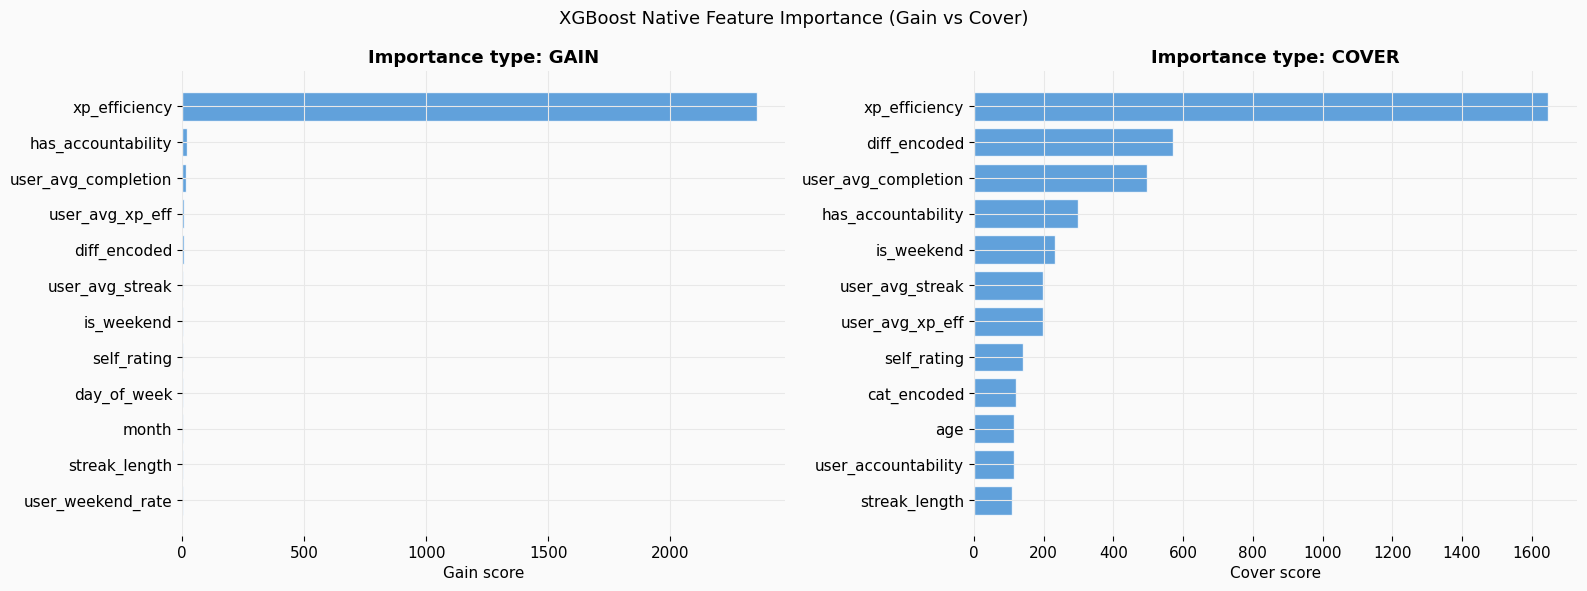


💡 Compare these rankings to SHAP — they'll differ slightly.
   Differences reveal where native importance has biases.
   SHAP is more trustworthy for communicating results to stakeholders.


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('XGBoost Native Feature Importance (Gain vs Cover)', fontsize=13)

for ax, importance_type in zip(axes, ['gain', 'cover']):
    scores = xgb_model.get_booster().get_score(importance_type=importance_type)
    sorted_scores = dict(sorted(scores.items(), key=lambda x: x[1], reverse=False)[-12:])

    ax.barh(
        list(sorted_scores.keys()),
        list(sorted_scores.values()),
        color=BLUE, alpha=0.8, edgecolor='white'
    )
    ax.set_title(f'Importance type: {importance_type.upper()}')
    ax.set_xlabel(f'{importance_type.capitalize()} score')

plt.tight_layout()
plt.savefig('../data/processed/plot_xgb_native_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 Compare these rankings to SHAP — they'll differ slightly.")
print("   Differences reveal where native importance has biases.")
print("   SHAP is more trustworthy for communicating results to stakeholders.")


## 13. Module 2 Summary — The Habit DNA

In [19]:
print("=" * 60)
print("MODULE 2 — HABIT DNA: KEY FINDINGS")
print("=" * 60)

xgb_auc = roc_auc_score(y_test, y_prob_xgb)
base_auc = roc_auc_score(y_test, y_prob_base)
lift     = (xgb_auc - base_auc) / base_auc * 100

print(f"\n1. Model Performance:")
print(f"   Logistic Regression AUC : {base_auc:.4f}")
print(f"   XGBoost AUC             : {xgb_auc:.4f}  (+{lift:.1f}% lift over baseline)")
print(f"   → XGBoost justified — meaningful improvement over simple baseline")

print(f"\n2. Top 5 Habit DNA drivers (by mean |SHAP|):")
mean_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=FEATURES)
for feat, val in mean_shap.sort_values(ascending=False).head(5).items():
    print(f"   {feat:<30} mean |SHAP| = {val:.4f}")

print(f"\n3. Behavioral segments found: 4")
for i in range(4):
    size = segment_meta.loc[i, 'size']
    rate = segment_meta.loc[i, 'actual_rate']
    top_driver = segment_profiles.loc[i, top6_features].idxmax()
    print(f"   Segment {i}: n={size:,}  completion={rate*100:.1f}%  top driver={top_driver}")

print(f"\n4. Accountability effect on predictions:")
acc_mean = shap_df['has_accountability'].mean()
print(f"   Mean |SHAP| for has_accountability: {acc_mean:.4f}")

print(f"\n→ NEXT: Notebook 04 — Burnout Risk Scoring")
print(f"  Building a composite 0–100 burnout index from StudentLife data")


MODULE 2 — HABIT DNA: KEY FINDINGS

1. Model Performance:
   Logistic Regression AUC : 0.9936
   XGBoost AUC             : 0.9929  (+-0.1% lift over baseline)
   → XGBoost justified — meaningful improvement over simple baseline

2. Top 5 Habit DNA drivers (by mean |SHAP|):
   xp_efficiency                  mean |SHAP| = 6.3727
   user_avg_completion            mean |SHAP| = 1.4135
   user_avg_xp_eff                mean |SHAP| = 0.6898
   has_accountability             mean |SHAP| = 0.1476
   self_rating                    mean |SHAP| = 0.1405

3. Behavioral segments found: 4
   Segment 0: n=2,292  completion=36.3%  top driver=xp_efficiency
   Segment 1: n=3,366  completion=100.0%  top driver=xp_efficiency
   Segment 2: n=2,878  completion=89.9%  top driver=xp_efficiency
   Segment 3: n=1,464  completion=10.9%  top driver=xp_efficiency

4. Accountability effect on predictions:
   Mean |SHAP| for has_accountability: 0.1476

→ NEXT: Notebook 04 — Burnout Risk Scoring
  Building a composit